# Evaluate Model Performance

## Import Evaluator Module

In [2]:
from util.Evaluator import Evaluator

## Load Model

In [ ]:
model_dir = "GAGEii-ALL_Gauges_Filtered_Periodically_Separate_0703_121713" # Specify the model name
epoch_num = 91 # Specify the epoch number
eval_dir = "metadata/csv_filtered" # Directory to the csv files for evaluation

# Call the Evaluator Class
evaluator = Evaluator(run_dir=model_dir, epoch_num=epoch_num, csv_dir=eval_dir,
                      test_start_date="01/01/2011",
                      test_end_date="31/12/2023")

C:\Users\ybrot\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\neuralhydrology\evaluation\tester.py:133: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub f

# Evaluation:  36%|███▌      | 348/975 [03:07<06:45,  1.55it/s]

## Plot the validation curve to possibly identify overfitting

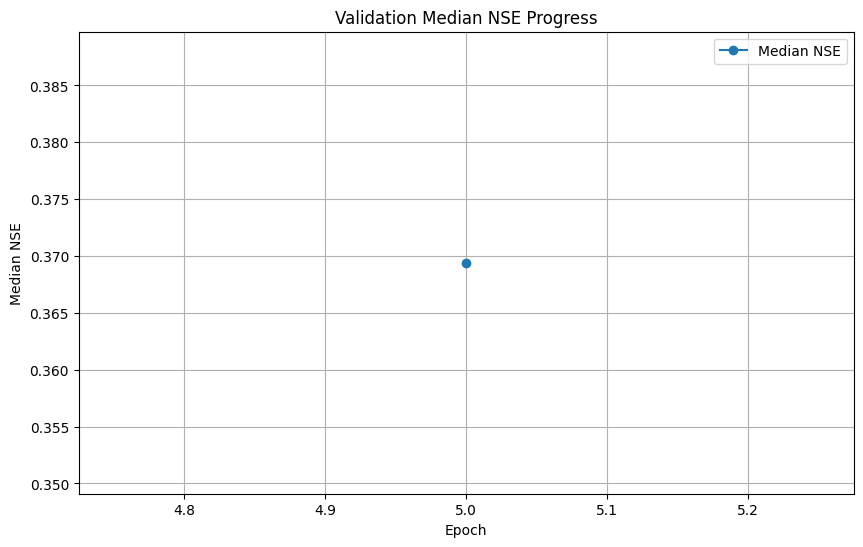

In [15]:
evaluator.plot_validation()

## Evaluation Results

In [16]:
print(evaluator)

Summary Statistic: 
count    172.000000
mean      -4.589934
std       44.511451
min     -576.640514
25%       -0.082836
50%        0.287107
75%        0.569783
max        0.814711
Name: NSE, dtype: float64

Performance Summary: 
Performance
Negative          71
Good              70
Unsatisfactory    46
Excellent          8
Name: count, dtype: int64

evaluate GAGEii-ALL_Gauges_Filtered_Regionally_Separate_0603_172605 epoch 5


## Scatterplot of NSE vs Coverage

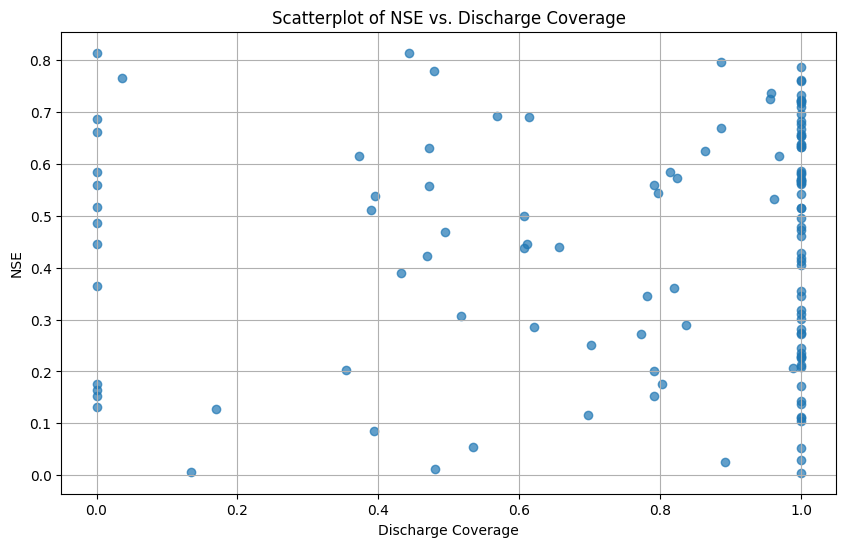

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

nse_df = evaluator.get_nse()
nse_df_filtered = nse_df[nse_df["NSE"] > 0]
coverage_df = pd.read_csv("metadata/coverage.csv")

# Merge the two dataframes on 'basin_id'
merged_df = pd.merge(nse_df_filtered, coverage_df, on="basin_id", how="inner")

# Create the scatterplot
plt.figure(figsize=(10, 6))
plt.scatter(merged_df["discharge_coverage"], merged_df["NSE"], alpha=0.7)
plt.xlabel("Discharge Coverage")
plt.ylabel("NSE")
plt.title("Scatterplot of NSE vs. Discharge Coverage")
plt.grid(True)
plt.show()

In [20]:
nse_df_filtered.describe()

,NSE
count,124.000000
mean,0.443243
std,0.225666
min,0.004537
25%,0.242770
50%,0.481666
75%,0.632778
max,0.814711
